# Data Exploration and Preperation - SAML-D
**Kaan Gogcay | AML Research**

This notebook explores and prepares the SAML-D dataset. The notebook is structured as follows:

<h2>Contents</h2>
- table of content here

---

# Data Split
Before any exploration is performed, the dataset will be split in a train, validation and test split. This is done so the exploration can be performed on the train set rather than the full dataset to prevent any possibility of data leakage. 

Since the dataset is temporal ([SAML-D Dataset](https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml)), the dataset is split chronologically to prevent data leakage (since in a real AML system, a model always scores future transactions using only past information). The dataset is split into a 70/15/15 ratio, because it is a common split size in machine learning. A validation set is required since cross-validation is not possible in a temporal dataset, since it would create data-leakage.

In [34]:
import pandas as pd
import numpy as np
import os

# Load data
df = pd.read_csv('../SAML-D.csv')
print(f'Dataset shape: {df.shape}')
print(f'Laundering rate: {df["Is_laundering"].mean() * 100:.4f}%')

# Sort chronologically
df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df = df.sort_values('datetime').reset_index(drop=True)

# Chronological 70/15/15 split — BEFORE feature engineering
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f'\nSplit sizes — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    rate = split['Is_laundering'].mean() * 100
    print(f'  {name} laundering rate: {rate:.4f}%')

Dataset shape: (9504852, 12)
Laundering rate: 0.1039%

Split sizes — Train: 6,653,396 | Val: 1,425,728 | Test: 1,425,728
  Train laundering rate: 0.1017%
  Val laundering rate: 0.0990%
  Test laundering rate: 0.1190%


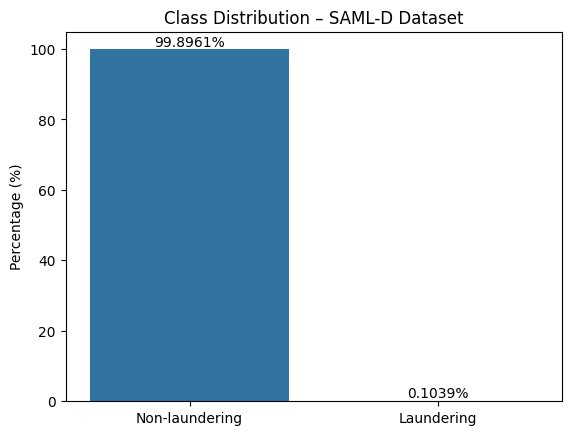

In [35]:
from matplotlib import pyplot as plt
import seaborn as sns

rates = df['Is_laundering'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(
    x=['Non-laundering', 'Laundering'],
    y=rates.values
)

# Add centered labels
for patch, value in zip(ax.patches, rates.values):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    ax.text(
        x,
        y + 0.02,
        f'{value:.4f}%',
        ha='center',
        va='bottom'
    )

plt.ylabel('Percentage (%)')
plt.title('Class Distribution – SAML-D Dataset')

plt.show()

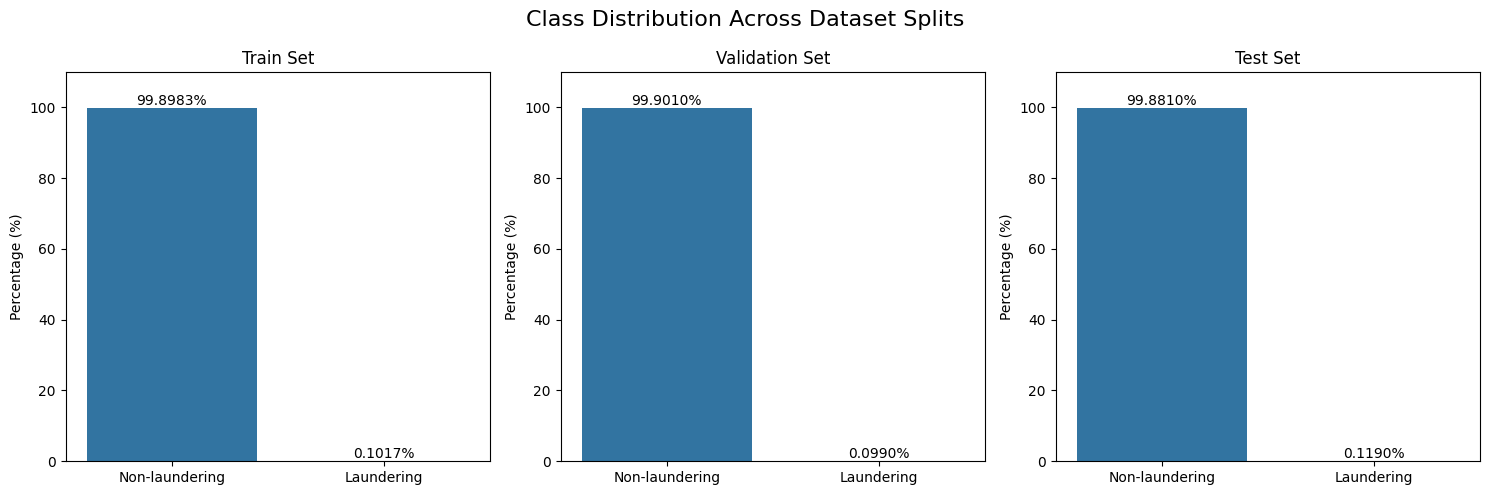

In [36]:
from matplotlib import pyplot as plt
import seaborn as sns

# Store splits
splits = {
    'Train': train_df,
    'Validation': val_df,
    'Test': test_df
}

# Create 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, split_df) in zip(axes, splits.items()):

    # Calculate percentages
    rates = (
        split_df['Is_laundering']
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    # Plot
    sns.barplot(
        x=['Non-laundering', 'Laundering'],
        y=rates.values,
        ax=ax
    )

    # Add centered labels
    for patch, value in zip(ax.patches, rates.values):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        ax.text(
            x,
            y + 0.02,
            f'{value:.4f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(f'{name} Set')
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, max(rates.values) * 1.1)

# Overall title
fig.suptitle('Class Distribution Across Dataset Splits', fontsize=16)

plt.tight_layout()
plt.show()

## Class Imbalance
The dataset is extremely imbalanced, with only a laundering percentage of 0.1039%. After splitting the dataset into train, val and test chronologically, the laundering rate is distributed evenly, with rates of 0.1017%, 0.0990% and 0.1190% respectively.

This is the last time the test set will be examined in the EDA. Making sure the test set contains enough laundering cases is a necesity. If the laundering percentage wouldn't be looked at in this phase of the project, it theoretically could have a rate of very close to 0 and the entire project could be meaningless.

# Data Exploration

## Available Features
The dataset contains 12 raw features. A `datetime` field is added manually by combining `Date` and `Time` for chronological sorting. Note that `Date`, `Time`, and `datetime` are used only for sorting and will be dropped before modelling.

| Feature | Definition | Example Value |
|-|-|-|
| `Time` | Time of transaction | 10:35:19 |
| `Date` | Date of transaction | 2022-10-07 |
| `Sender_account` | Id of the account of the sender | 8724731955 |
| `Receiver_account` | Id of the account of the receiver | 2769355426 |
| `Amount` | Transaction amount | 1459.15 |
| `Payment_currency` | Currency of the sender | UK pounds |
| `Received_currency` | Currency of the receiver | UK pounds |
| `Sender_bank_location` | Bank country of the sender | UK |
| `Receiver_bank_location` | Bank country of the receiver | UK |
| `Payment_type` | Payment method | Cash Deposit |
| `Is_laundering` | indication if transaction is laundred | 0 |
| `Laundering_type` | The type of laundering linked to the transaction | Normal_Cash_Deposits | 
| `datetime` | feature added for chronological split | 2022-10-07 10:35:19 |

`Payment_type` and `Laundering_type` are categorical and not self-explanatory and therefore require further explanation.

**Payment types (7 total):**

| Payment_type | Definition |
|-|-|
| Cash Deposit | Depositing physical cash into a bank account (for example at an ATM) |
| Cross-border | A transfer sent internationally across country borders |
| Cheque | A written paper instruction ordering a bank to pay a specified amount from one account to another |
| ACH | Automated Clearing House - an electronic batch payment system used for direct debits and bank transfers |
| Credit card | A payment made using a credit card |
| Debit card | A payment made using a debit card |
| Cash Withdrawal | Withdrawing physical cash from a bank account (for example at an ATM) |

**Transaction typologies (28 total, 11 normal and 17 suspicious)**

| Laundering_type | Suspicious | Definition |
|---|---|---|
| Normal_Cash_Deposits | No | A normal cash deposit into a bank account |
| Normal_Fan_Out | No |One account sending transactions to many different receivers, normal behaviour such as a business paying suppliers |
| Normal_Small_Fan_Out | No | One account sending small-amount transactions to many different receivers, normal behaviour such as splitting a bill |
| Normal_Fan_In | No | One account receiving transactions from many different senders, normal behaviour such as a business collecting customer payments |
| Normal_Group | No | An account that regularly transacts with a fixed group of accounts |
| Normal_Cash_Withdrawal | No | A normal cash withdrawal from a bank account |
| Normal_Periodical | No | An account making regular periodic transactions, normal behaviour such as monthly rent or subscription payments |
| Normal_Foward | No | An account receiving money and forwarding it to another account, normal behaviour such as passing on a reimbursement |
| Normal_Mutual | No | Two accounts that regularly send money back and forth to each other, normal behaviour such as two friends splitting costs |
| Normal_Plus_Mutual | No | A Normal_Group pattern extended with mutual transactions between the main account and its group members |
| Normal_single_large | No | A single large transaction that is normal in context, such as a house purchase or large business invoice |
| Smurfing | Yes | Breaking a large amount into many small transactions across multiple accounts to avoid detection thresholds, placement stage |
| Structuring | Yes | Deliberately keeping transactions just below reporting thresholds to avoid triggering regulatory scrutiny, placement stage |
| Cash_Withdrawal | Yes | Suspicious low-value cash withdrawals used to facilitate crimes such as forced servitude |
| Behavioural_Change_1 | Yes | An account that deviates from its Normal_Group pattern by suddenly transacting with new unknown accounts |
| Behavioural_Change_2 | Yes | An account that deviates from its Normal_Group pattern by suddenly transacting with new accounts in high-risk locations |
| Layered_Fan_In | Yes | A multi-layer Fan_In where funds pass through intermediate accounts before aggregating into a final destination, layering stage |
| Layered_Fan_Out | Yes | A multi-layer Fan_Out where funds pass through intermediate accounts before being scattered to final destinations, layering stage |
| Scatter-Gather | Yes | Funds are first scattered from one account to many, then regathered into a single destination account |
| Cycle | Yes | Money moves in a circular chain across multiple accounts, eventually returning to the originating account |
| Fan_In | Yes | Many accounts rapidly sending similar amounts to one central account, suspicious aggregation of laundered funds |
| Stacked Bipartite | Yes | Multiple layered bipartite networks stacked on top of each other to add complexity and obscure the money trail |
| Over-Invoicing | Yes | Inflating the value of goods or services in cross-border transactions to move money internationally under a legitimate cover |
| Deposit-Send | Yes | An account deposits cash and rapidly sends it onwards to another account, often below reporting thresholds and to high-risk countries |
| Single_large | Yes | A single unusually large transaction that stands out significantly from the account's normal transaction history |
| Bipartite | Yes | A fixed set of sender accounts transacting exclusively with a fixed set of receiver accounts, creating an isolated suspicious subnetwork |
| Gather-Scatter | Yes | Funds are first gathered from many sources into one account, then scattered to many destinations, combining Fan_In and Fan_Out |
| Fan_Out | Yes | One account rapidly sending money to many different receivers simultaneously, suspicious dispersal of laundered funds |

# XGBoost Model - Raw Features
 

In [37]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    classification_report,
)
import matplotlib.pyplot as plt


# =============================================================================
# 1. LOAD SPLITS
# =============================================================================
train_df = train_df # hierboven
val_df   = val_df # hierboven
test_df  = test_df # hierboven

In [38]:
# =============================================================================
# 2. PREPARE FEATURES
# Drop: target and label-leaking column (Laundering_type kept in CSVs for dashboard)
# =============================================================================
DROP_COLS = ["Is_laundering", "Laundering_type", "Date", "Time", "datetime"]

def prepare(split_df):
    X = split_df.drop(columns=DROP_COLS)
    y = split_df["Is_laundering"]
    return X, y

X_train, y_train = prepare(train_df)
X_val,   y_val   = prepare(val_df)
X_test,  y_test  = prepare(test_df)

# Convert object columns to category dtype (XGBoost native categorical support)
cat_cols = X_train.select_dtypes("object").columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")
    X_test[col]  = X_test[col].astype("category")

print(f"\nFeatures: {X_train.columns.tolist()}")
print(f"Categorical features: {cat_cols}")


Features: ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
Categorical features: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']


## Class Weights

The training set contains ~982 normal transactions for every 1 laundering transaction. Without correction, XGBoost will learn that predicting Normal for everything produces a very low loss — because it is right 99.9% of the time — and effectively ignore the laundering class entirely.

`scale_pos_weight = neg / pos` tells XGBoost to treat each misclassified laundering transaction as if it were 982 misclassified normal transactions, forcing the model to take the minority class seriously during training.

In [39]:
# =============================================================================
# 3. CLASS IMBALANCE WEIGHT
# =============================================================================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"\nClass balance — Neg: {neg:,} | Pos: {pos:,} | scale_pos_weight: {scale_pos_weight:.1f}")


Class balance — Neg: 6,646,632 | Pos: 6,764 | scale_pos_weight: 982.6


In [40]:
# =============================================================================
# 4. TRAIN MODEL
# =============================================================================
model = xgb.XGBClassifier(
    tree_method="hist",        # Required: 9.5M rows, hist is the only practical choice
    enable_categorical=True,   # Required: native categorical support for your features
    scale_pos_weight=neg/pos,  # Required: 0.104% imbalance, mathematically justified
    eval_metric="aucpr",       # Required: matches your primary evaluation metric
    early_stopping_rounds=50,  # Required: needs validation set, prevents overfitting
    random_state=42,           # Required: reproducibility safeguard
    n_jobs=-1,                 # Practical: use all cores
    device="cuda"              # Practical: GPU training for speed (if available)
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-aucpr:0.06712
[50]	validation_0-aucpr:0.07139
[99]	validation_0-aucpr:0.07649

Best iteration: 95


In [41]:
# =============================================================================
# 5. EVALUATE — PRIMARY METRIC: AUPRC
# =============================================================================
def evaluate(model, X, y, split_name):
    y_proba = model.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f"\n{'='*50}")
    print(f"{split_name} AUPRC: {auprc:.4f}")
    return y_proba, auprc

y_val_proba,  val_auprc  = evaluate(model, X_val,  y_val,  "Validation")

y_val_pred = (y_val_proba >= 0.5).astype(int)
print("\nClassification report at 0.5 threshold (informational):")
print(classification_report(y_val, y_val_pred, target_names=["Normal", "Laundering"]))


Validation AUPRC: 0.0770

Classification report at 0.5 threshold (informational):
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94   1424316
  Laundering       0.00      0.50      0.01      1412

    accuracy                           0.89   1425728
   macro avg       0.50      0.70      0.48   1425728
weighted avg       1.00      0.89      0.94   1425728



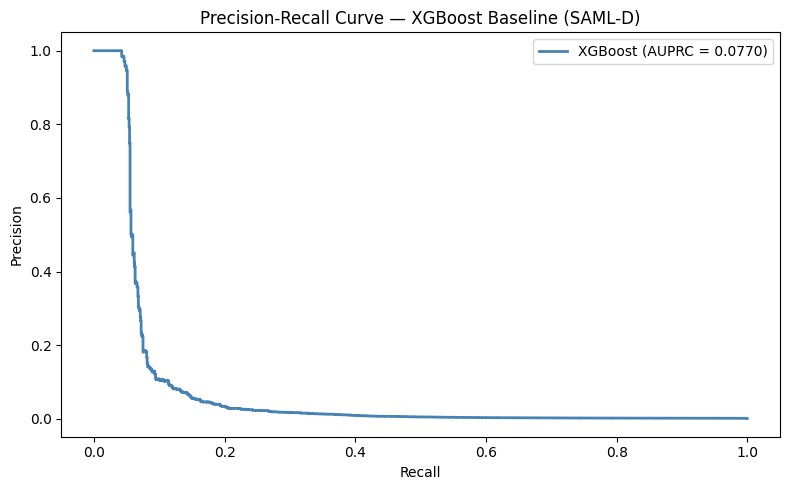

Saved: pr_curve_xgboost.png


In [42]:
# =============================================================================
# 6. PRECISION-RECALL CURVE PLOT
# =============================================================================
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color="steelblue", lw=2,
         label=f"XGBoost (AUPRC = {val_auprc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline (SAML-D)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_xgboost.png", dpi=150)
plt.show()
print("Saved: pr_curve_xgboost.png")

## Evaluation - Raw Features
The area under the precision recall curve is very small with only an area of 0.0770. Below an analysis of what patterns are succesfully captured and which aren't. The pattern being detected the least is `Fan_Out` with only a catch rate of 18.39%. To improve this, Feature engineering will be applied

     Laundering_type  total  caught  missed  catch_rate
             Fan_Out   87.0    16.0    71.0   18.390805
      Layered_Fan_In   92.0    17.0    75.0   18.478261
     Layered_Fan_Out   53.0    11.0    42.0   20.754717
      Scatter-Gather   43.0     9.0    34.0   20.930233
      Gather-Scatter   43.0    10.0    33.0   23.255814
              Fan_In   68.0    17.0    51.0   25.000000
Behavioural_Change_1   71.0    20.0    51.0   28.169014
               Cycle   66.0    19.0    47.0   28.787879
           Bipartite   37.0    11.0    26.0   29.729730
   Stacked Bipartite   93.0    29.0    64.0   31.182796
         Structuring  194.0    95.0    99.0   48.969072
Behavioural_Change_2   86.0    44.0    42.0   51.162791
      Over-Invoicing   14.0     9.0     5.0   64.285714
        Single_large   31.0    21.0    10.0   67.741935
        Deposit-Send  134.0    94.0    40.0   70.149254
     Cash_Withdrawal  173.0   165.0     8.0   95.375723
            Smurfing  127.0   122.0     5.0   96

C:\Users\thezo\AppData\Local\Temp\ipykernel_12044\2036978821.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_results = laundering_val.groupby('Laundering_type').apply(


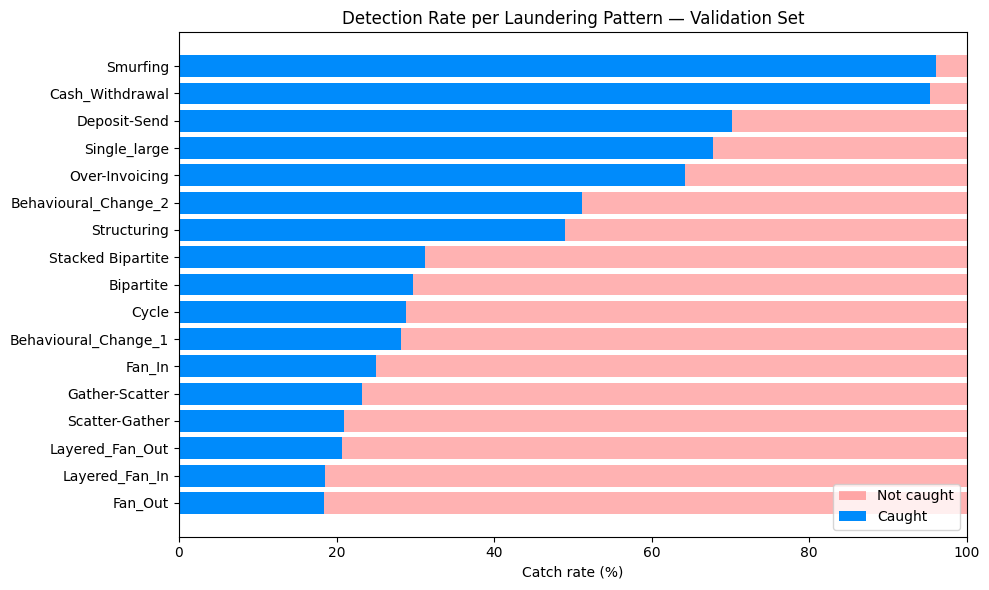

In [43]:
# Per-pattern detection analysis on validation set
THRESHOLD = 0.5

val_analysis = val_df.copy()
val_analysis['predicted_score'] = y_val_proba
val_analysis['predicted_label'] = (y_val_proba >= THRESHOLD).astype(int)

# Only look at actual laundering transactions
laundering_val = val_analysis[val_analysis['Is_laundering'] == 1]

# Per pattern: how many were caught?
pattern_results = laundering_val.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index().sort_values('catch_rate', ascending=True)

print(pattern_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

# Red background bar (full 100% — not caught)
ax.barh(pattern_results['Laundering_type'], 100,
        color="#ff0000", alpha=0.3, label='Not caught')

# Blue foreground bar (caught)
ax.barh(pattern_results['Laundering_type'], pattern_results['catch_rate'],
        color='#008bfb', label='Caught')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 100)
ax.set_title('Detection Rate per Laundering Pattern — Validation Set')
ax.legend()
plt.tight_layout()
plt.savefig('pattern_detection_rate.png', dpi=150)
plt.show()

# Feature Engineering - Fan_Out
Looking at the raw on both the non-suspicious and suspicious transactions, it isn't clear which ones are laundred and which aren't. Therefore it makes sense that this is the pattern the model struggles the most with. Below all possible features I could come up with with the given raw features.

In [44]:
# Print 5 Normal_Fan_Out and 5 Fan_Out transactions from training set
for pattern in ['Normal_Fan_Out', 'Fan_Out']:
    print(f'\n{"="*60}')
    print(f'{pattern} — 5 example transactions')
    print(f'{"="*60}')
    sample = train_df[train_df['Laundering_type'] == pattern].head(5)
    print(sample.to_string(index=False))


Normal_Fan_Out — 5 example transactions
    Time       Date  Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type            datetime
10:35:20 2022-10-07      1491989064        8401255335  6019.64        UK pounds            Dirham                   UK                    UAE Cross-border              0  Normal_Fan_Out 2022-10-07 10:35:20
10:35:26 2022-10-07      6116657264         656192169  4738.45        UK pounds         UK pounds                   UK                     UK       Cheque              0  Normal_Fan_Out 2022-10-07 10:35:26
10:35:29 2022-10-07      7421451752        2755709071  5883.87     Indian rupee         UK pounds                   UK                     UK  Credit card              0  Normal_Fan_Out 2022-10-07 10:35:29
10:35:46 2022-10-07      3709430533        9172843471  5274.76        UK pounds         UK pounds                   UK                 

In [45]:
DROP_COLS = ['datetime', 'Date', 'Time']
train_df = train_df.drop(columns=DROP_COLS)
val_df   = val_df.drop(columns=DROP_COLS)
test_df  = test_df.drop(columns=DROP_COLS)

# Sender-level aggregates — computed on train only
sender_agg = train_df.groupby('Sender_account').agg(
    sender_tx_count         =('Amount', 'count'),
    sender_amount_mean      =('Amount', 'mean'),
    sender_amount_std       =('Amount', 'std'),
    sender_amount_min       =('Amount', 'min'),
    sender_amount_max       =('Amount', 'max'),
    sender_unique_receivers =('Receiver_account', 'nunique'),
    sender_unique_currencies=('Payment_currency', 'nunique'),
    sender_unique_locations =('Receiver_bank_location', 'nunique'),
).reset_index()

# Receiver-level aggregates — computed on train only
receiver_agg = train_df.groupby('Receiver_account').agg(
    receiver_tx_count         =('Amount', 'count'),
    receiver_amount_mean      =('Amount', 'mean'),
    receiver_amount_std       =('Amount', 'std'),
    receiver_unique_senders   =('Sender_account', 'nunique'),
    receiver_unique_currencies=('Received_currency', 'nunique'),
    receiver_unique_locations =('Sender_bank_location', 'nunique'),
).reset_index()

# Account duality sets — from training history only
train_sender_set   = set(train_df['Sender_account'].unique())
train_receiver_set = set(train_df['Receiver_account'].unique())

def add_features(split_df, sender_agg, receiver_agg, train_sender_set, train_receiver_set):
    df = split_df.copy()
    df = df.merge(sender_agg,   on='Sender_account',   how='left')
    df = df.merge(receiver_agg, on='Receiver_account', how='left')
    agg_cols = (
        list(sender_agg.columns.drop('Sender_account')) +
        list(receiver_agg.columns.drop('Receiver_account'))
    )
    df[agg_cols] = df[agg_cols].fillna(0)
    df['fan_out_ratio'] = df['sender_unique_receivers'] / df['sender_tx_count'].replace(0, 1)
    df['fan_in_ratio']  = df['receiver_unique_senders'] / df['receiver_tx_count'].replace(0, 1)
    df['is_cross_currency'] = (df['Payment_currency'] != df['Received_currency']).astype(int)
    df['is_cross_border']   = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)
    return df

train_df_fe = add_features(train_df, sender_agg, receiver_agg, train_sender_set, train_receiver_set)
val_df_fe   = add_features(val_df,   sender_agg, receiver_agg, train_sender_set, train_receiver_set)
test_df_fe  = add_features(test_df,  sender_agg, receiver_agg, train_sender_set, train_receiver_set)

print(f'Features after engineering: {train_df_fe.shape[1]} columns')

Features after engineering: 28 columns


## Fan-Out
Now it becomes more clear. Suspicious Fan-Out transactions can be detected by looking at the newly created feature `sender_tx_count`, where in all the flagged transactions this number is very low.

In [46]:
# Print 5 Normal_Fan_Out and 5 Fan_Out transactions from training set
for pattern in ['Normal_Fan_Out', 'Fan_Out']:
    print(f'\n{"="*60}')
    print(f'{pattern} — 5 example transactions')
    print(f'{"="*60}')
    sample = train_df_fe[train_df_fe['Laundering_type'] == pattern].head(5)
    print(sample.to_string(index=False))


Normal_Fan_Out — 5 example transactions
 Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border
     1491989064        8401255335  6019.64        UK pounds            Dirham                   UK                    UAE Cross-border              0  Normal_Fan_Out              368         6888.261141       28630.387620              10.37          539159.80                       46                         4                        6                 12           6021.031667            31.635744                   

# XGBoost Model - Feature Engineered
Rather than analysing each laundering pattern in order to predict how well the model will perform, A new model will be trained instead on the engineered features.

In [47]:
# Prepare feature engineered splits
DROP_COLS_FE = ['Is_laundering', 'Laundering_type']

X_train2, y_train2 = train_df_fe.drop(columns=DROP_COLS_FE), train_df_fe['Is_laundering']
X_val2,   y_val2   = val_df_fe.drop(columns=DROP_COLS_FE),   val_df_fe['Is_laundering']
X_test2,  y_test2  = test_df_fe.drop(columns=DROP_COLS_FE),  test_df_fe['Is_laundering']

cat_cols2 = X_train2.select_dtypes('object').columns.tolist()
for col in cat_cols2:
    X_train2[col] = X_train2[col].astype('category')
    X_val2[col]   = X_val2[col].astype('category')
    X_test2[col]  = X_test2[col].astype('category')

print(f'Features: {X_train2.columns.tolist()}')

# =============================================================================
# TRAIN MODEL 2 — Feature Engineered
# =============================================================================
model2 = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    device='cuda'
)

model2.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    verbose=50,
)

print(f'\nBest iteration: {model2.best_iteration}')

Features: ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'sender_tx_count', 'sender_amount_mean', 'sender_amount_std', 'sender_amount_min', 'sender_amount_max', 'sender_unique_receivers', 'sender_unique_currencies', 'sender_unique_locations', 'receiver_tx_count', 'receiver_amount_mean', 'receiver_amount_std', 'receiver_unique_senders', 'receiver_unique_currencies', 'receiver_unique_locations', 'fan_out_ratio', 'fan_in_ratio', 'is_cross_currency', 'is_cross_border']
[0]	validation_0-aucpr:0.02498
[50]	validation_0-aucpr:0.76902
[83]	validation_0-aucpr:0.76805

Best iteration: 34


In [48]:
# =============================================================================
# 5. EVALUATE — PRIMARY METRIC: AUPRC
# =============================================================================
def evaluate(model, X, y, split_name):
    y_proba = model.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f"\n{'='*50}")
    print(f"{split_name} AUPRC: {auprc:.4f}")
    return y_proba, auprc

y_val_proba2, val_auprc2  = evaluate(model2, X_val2,  y_val2,  "Validation")

y_val_pred2 = (y_val_proba2 >= 0.5).astype(int)
print("\nClassification report at 0.5 threshold (informational):")
print(classification_report(y_val2, y_val_pred2, target_names=["Normal", "Laundering"]))


Validation AUPRC: 0.7704

Classification report at 0.5 threshold (informational):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424316
  Laundering       0.37      0.77      0.50      1412

    accuracy                           1.00   1425728
   macro avg       0.69      0.88      0.75   1425728
weighted avg       1.00      1.00      1.00   1425728



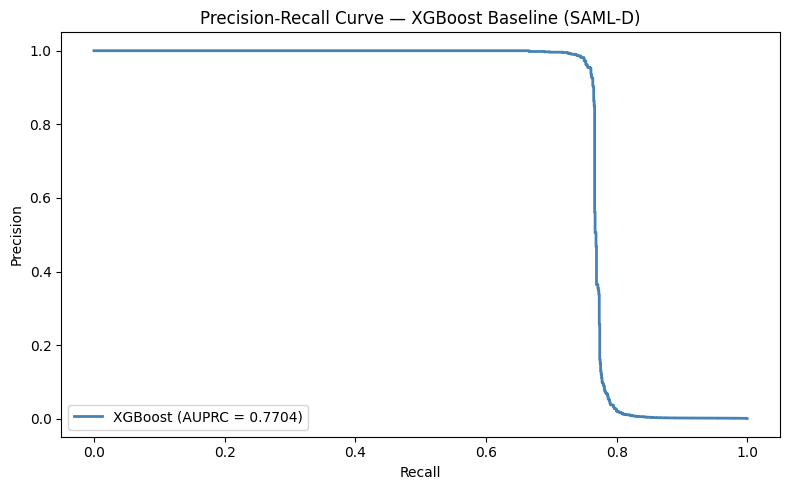

Saved: pr_curve_xgboost_2.png


In [49]:
# =============================================================================
# 6. PRECISION-RECALL CURVE PLOT
# =============================================================================
precision2, recall2, thresholds2 = precision_recall_curve(y_val2, y_val_proba2)

plt.figure(figsize=(8, 5))
plt.plot(recall2, precision2, color="steelblue", lw=2,
         label=f"XGBoost (AUPRC = {val_auprc2:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline (SAML-D)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_xgboost.png", dpi=150)
plt.show()
print("Saved: pr_curve_xgboost_2.png")

C:\Users\thezo\AppData\Local\Temp\ipykernel_12044\3441151326.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_results = laundering_val2.groupby('Laundering_type').apply(


     Laundering_type  total  caught  missed  catch_rate
      Scatter-Gather   43.0    15.0    28.0   34.883721
              Fan_In   68.0    33.0    35.0   48.529412
      Over-Invoicing   14.0     7.0     7.0   50.000000
     Layered_Fan_Out   53.0    27.0    26.0   50.943396
      Layered_Fan_In   92.0    49.0    43.0   53.260870
      Gather-Scatter   43.0    24.0    19.0   55.813953
               Cycle   66.0    37.0    29.0   56.060606
             Fan_Out   87.0    49.0    38.0   56.321839
   Stacked Bipartite   93.0    54.0    39.0   58.064516
           Bipartite   37.0    29.0     8.0   78.378378
        Single_large   31.0    25.0     6.0   80.645161
        Deposit-Send  134.0   110.0    24.0   82.089552
            Smurfing  127.0   119.0     8.0   93.700787
         Structuring  194.0   185.0     9.0   95.360825
     Cash_Withdrawal  173.0   166.0     7.0   95.953757
Behavioural_Change_2   86.0    86.0     0.0  100.000000
Behavioural_Change_1   71.0    71.0     0.0  100

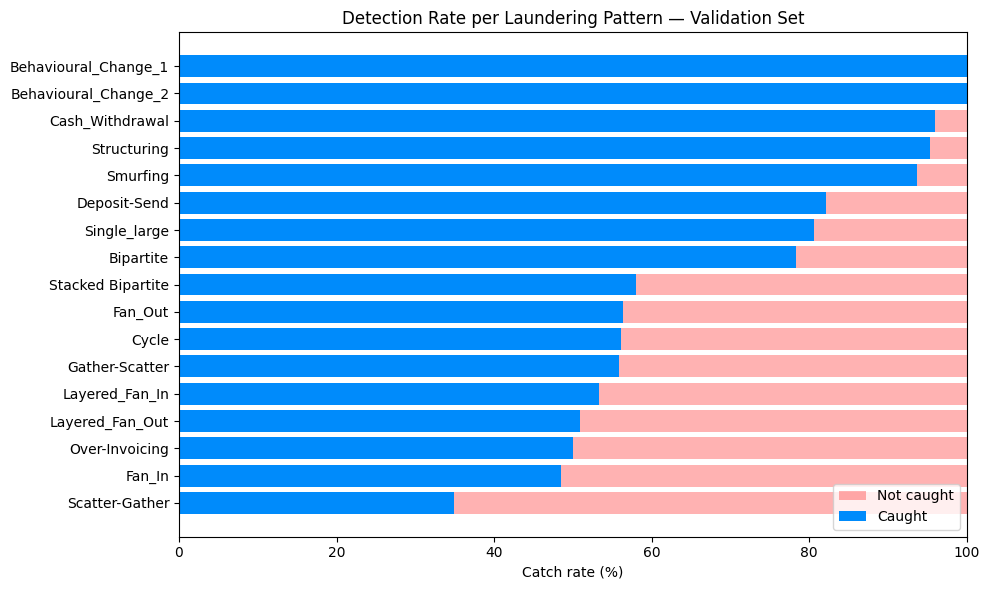

In [58]:
# Per-pattern detection analysis on validation set
THRESHOLD = 0.5

val_analysis2 = val_df_fe.copy()
val_analysis2['predicted_score'] = y_val_proba2
val_analysis2['predicted_label'] = (y_val_proba2 >= THRESHOLD).astype(int)

# Only look at actual laundering transactions
laundering_val2 = val_analysis2[val_analysis2['Is_laundering'] == 1]

# Per pattern: how many were caught?
pattern_results = laundering_val2.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index().sort_values('catch_rate', ascending=True)

print(pattern_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

# Red background bar (full 100% — not caught)
ax.barh(pattern_results['Laundering_type'], 100,
        color="#ff0000", alpha=0.3, label='Not caught')

# Blue foreground bar (caught)
ax.barh(pattern_results['Laundering_type'], pattern_results['catch_rate'],
        color='#008bfb', label='Caught')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 100)
ax.set_title('Detection Rate per Laundering Pattern — Validation Set')
ax.legend()
plt.tight_layout()
plt.savefig('pattern_detection_rate.png', dpi=150)
plt.show()

## Evaluating Results
Overall, all patterns are being detected better than before. However, Fan_Out is still on the lower side of the spectrum. Therefore I will analyze some predicted transactions.

It stands out that all the missed cases have a receiver_unique_sender of 0-1 and the once caught have 2 or more. Meaning, once there is an account that is only transacting with one other account this is not seen as suspicious by the model. But looking at the transactions that are labeled Normal_Fan_Out, this makes sense, since usually receiver_unique_sender is 0 or 1.

To be able to differentiate the Fan out from the normal fan out, a new feature must be created. It stood out that fan out transactions tend to come from the same account, therefore it would be beneficial if transactions between the same users would be kept getting track of.

In [64]:
# Print Fan_Out transactions — suspicious and normal, caught and missed
n=10

fan_out_val = val_analysis2[val_analysis2['Laundering_type'] == 'Fan_Out']
normal_fan_out_val = val_analysis2[val_analysis2['Laundering_type'] == 'Normal_Fan_Out']

print(f'\n{"="*60}')
print('Fan_Out (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)')
print(f'{"="*60}')
print(fan_out_val[fan_out_val['predicted_label'] == 1].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Fan_Out (SUSPICIOUS) — predicted NORMAL (missed)')
print(f'{"="*60}')
print(fan_out_val[fan_out_val['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal_Fan_Out (NORMAL) — predicted NORMAL (correctly ignored)')
print(f'{"="*60}')
print(normal_fan_out_val[normal_fan_out_val['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal_Fan_Out (NORMAL) — predicted SUSPICIOUS (false positive)')
print(f'{"="*60}')
print(normal_fan_out_val[normal_fan_out_val['predicted_label'] == 1].head(n ).to_string(index=False))


Fan_Out (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)
 Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border  predicted_score  predicted_label
     9163385117        4418736003 12130.24        UK pounds         UK pounds                   UK                     UK   Debit card              1         Fan_Out            160.0         5213.660875        6610.233996             124.93           27490.75                     23.0                       2.0                      3.0              107.0     

In [65]:
# Pair-level aggregate — computed on train only
# pair_tx_count = 0 means this sender-receiver pair has never transacted before in training
pair_agg = train_df.groupby(['Sender_account', 'Receiver_account']).size().reset_index(name='pair_tx_count')

In [66]:
def add_features_p(split_df, sender_agg, receiver_agg, pair_agg):
    df = split_df.copy()
    df = df.merge(sender_agg, on='Sender_account', how='left')
    df = df.merge(receiver_agg, on='Receiver_account', how='left')
    df = df.merge(pair_agg, on=['Sender_account', 'Receiver_account'], how='left')
    
    agg_cols = (
        list(sender_agg.columns.drop('Sender_account')) +
        list(receiver_agg.columns.drop('Receiver_account'))
    )
    df[agg_cols] = df[agg_cols].fillna(0)
    df['pair_tx_count'] = df['pair_tx_count'].fillna(0)  # 0 = never seen this pair before
    
    df['fan_out_ratio']     = df['sender_unique_receivers'] / df['sender_tx_count'].replace(0, 1)
    df['fan_in_ratio']      = df['receiver_unique_senders'] / df['receiver_tx_count'].replace(0, 1)
    df['is_cross_currency'] = (df['Payment_currency'] != df['Received_currency']).astype(int)
    df['is_cross_border']   = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)
    return df

train_df_fe2 = add_features_p(train_df, sender_agg, receiver_agg, pair_agg)
val_df_fe2   = add_features_p(val_df,   sender_agg, receiver_agg, pair_agg)
test_df_fe2  = add_features_p(test_df,  sender_agg, receiver_agg, pair_agg)

In [67]:
# Prepare feature engineered splits
DROP_COLS_FE = ['Is_laundering', 'Laundering_type']

X_train3, y_train3 = train_df_fe2.drop(columns=DROP_COLS_FE), train_df_fe2['Is_laundering']
X_val3,   y_val3   = val_df_fe2.drop(columns=DROP_COLS_FE),   val_df_fe2['Is_laundering']
X_test3,  y_test3  = test_df_fe2.drop(columns=DROP_COLS_FE),  test_df_fe2['Is_laundering']

cat_cols3 = X_train3.select_dtypes('object').columns.tolist()
for col in cat_cols3:
    X_train3[col] = X_train3[col].astype('category')
    X_val3[col]   = X_val3[col].astype('category')
    X_test3[col]  = X_test3[col].astype('category')

print(f'Features: {X_train3.columns.tolist()}')

# =============================================================================
# TRAIN MODEL 3 — Feature Engineered
# =============================================================================
model3 = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    device='cuda'
)

model3.fit(
    X_train3, y_train3,
    eval_set=[(X_val3, y_val3)],
    verbose=50,
)

print(f'\nBest iteration: {model3.best_iteration}')

Features: ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'sender_tx_count', 'sender_amount_mean', 'sender_amount_std', 'sender_amount_min', 'sender_amount_max', 'sender_unique_receivers', 'sender_unique_currencies', 'sender_unique_locations', 'receiver_tx_count', 'receiver_amount_mean', 'receiver_amount_std', 'receiver_unique_senders', 'receiver_unique_currencies', 'receiver_unique_locations', 'pair_tx_count', 'fan_out_ratio', 'fan_in_ratio', 'is_cross_currency', 'is_cross_border']
[0]	validation_0-aucpr:0.78776
[50]	validation_0-aucpr:0.90826
[99]	validation_0-aucpr:0.90247

Best iteration: 63


In [68]:
# =============================================================================
# 5. EVALUATE — PRIMARY METRIC: AUPRC
# =============================================================================
def evaluate(model, X, y, split_name):
    y_proba = model.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f"\n{'='*50}")
    print(f"{split_name} AUPRC: {auprc:.4f}")
    return y_proba, auprc

y_val_proba3, val_auprc3  = evaluate(model3, X_val3,  y_val3,  "Validation")

y_val_pred3 = (y_val_proba3 >= 0.5).astype(int)
print("\nClassification report at 0.5 threshold (informational):")
print(classification_report(y_val3, y_val_pred3, target_names=["Normal", "Laundering"]))


Validation AUPRC: 0.9087

Classification report at 0.5 threshold (informational):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424316
  Laundering       0.40      0.91      0.55      1412

    accuracy                           1.00   1425728
   macro avg       0.70      0.95      0.78   1425728
weighted avg       1.00      1.00      1.00   1425728



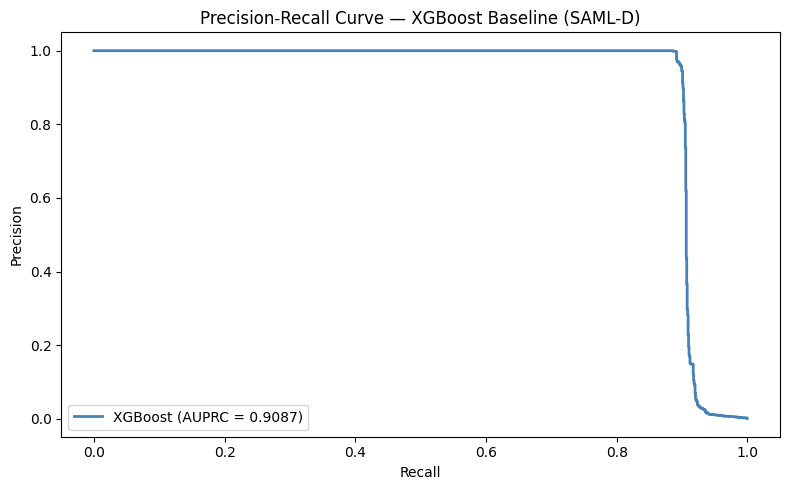

Saved: pr_curve_xgboost_3.png


In [69]:
# =============================================================================
# 6. PRECISION-RECALL CURVE PLOT
# =============================================================================
precision3, recall3, thresholds3 = precision_recall_curve(y_val3, y_val_proba3)

plt.figure(figsize=(8, 5))
plt.plot(recall3, precision3, color="steelblue", lw=2,
         label=f"XGBoost (AUPRC = {val_auprc3:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline (SAML-D)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_xgboost_3.png", dpi=150)
plt.show()
print("Saved: pr_curve_xgboost_3.png")

C:\Users\thezo\AppData\Local\Temp\ipykernel_12044\1570022507.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_results = laundering_val3.groupby('Laundering_type').apply(


     Laundering_type  total  caught  missed  catch_rate
      Scatter-Gather   43.0    29.0    14.0   67.441860
      Layered_Fan_In   92.0    66.0    26.0   71.739130
               Cycle   66.0    53.0    13.0   80.303030
      Gather-Scatter   43.0    36.0     7.0   83.720930
              Fan_In   68.0    57.0    11.0   83.823529
      Over-Invoicing   14.0    12.0     2.0   85.714286
   Stacked Bipartite   93.0    81.0    12.0   87.096774
             Fan_Out   87.0    76.0    11.0   87.356322
     Layered_Fan_Out   53.0    47.0     6.0   88.679245
           Bipartite   37.0    33.0     4.0   89.189189
            Smurfing  127.0   119.0     8.0   93.700787
        Deposit-Send  134.0   127.0     7.0   94.776119
     Cash_Withdrawal  173.0   167.0     6.0   96.531792
        Single_large   31.0    30.0     1.0   96.774194
         Structuring  194.0   191.0     3.0   98.453608
Behavioural_Change_2   86.0    86.0     0.0  100.000000
Behavioural_Change_1   71.0    71.0     0.0  100

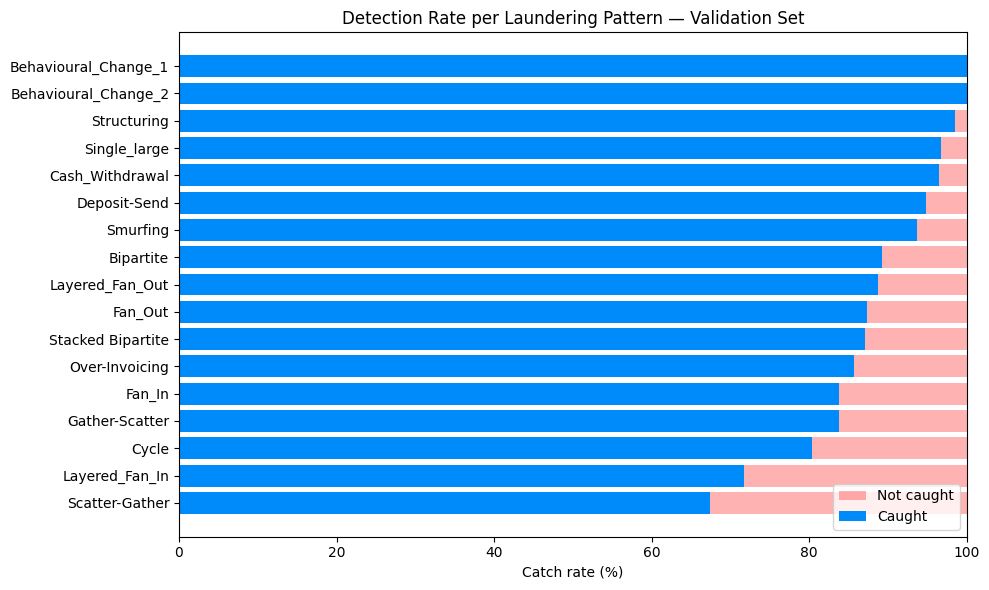

In [70]:
# Per-pattern detection analysis on validation set
THRESHOLD = 0.5

val_analysis3 = val_df_fe2.copy()
val_analysis3['predicted_score'] = y_val_proba3
val_analysis3['predicted_label'] = (y_val_proba3 >= THRESHOLD).astype(int)

# Only look at actual laundering transactions
laundering_val3 = val_analysis3[val_analysis3['Is_laundering'] == 1]

# Per pattern: how many were caught?
pattern_results = laundering_val3.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index().sort_values('catch_rate', ascending=True)

print(pattern_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

# Red background bar (full 100% — not caught)
ax.barh(pattern_results['Laundering_type'], 100,
        color="#ff0000", alpha=0.3, label='Not caught')

# Blue foreground bar (caught)
ax.barh(pattern_results['Laundering_type'], pattern_results['catch_rate'],
        color='#008bfb', label='Caught')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 100)
ax.set_title('Detection Rate per Laundering Pattern — Validation Set')
ax.legend()
plt.tight_layout()
plt.savefig('pattern_detection_rate.png', dpi=150)
plt.show()

## Evaluation Catch Rates
Again, all patterns' detection rates went up, with the lowest being scatter-gather sitting at 67.44%, followed by layered_fan_in and cycle.